In [1]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

metadata_path = r"C:\computer vision\case study\skin ham dataset\HAM10000_metadata.csv"
image_dir1 = r"C:\computer vision\case study\skin ham dataset\HAM10000_images_part_1"
image_dir2 = r"C:\computer vision\case study\skin ham dataset\HAM10000_images_part_2"

df = pd.read_csv(metadata_path)

# Create image path column
paths = []
for img_id in df['image_id']:
    p1 = os.path.join(image_dir1, img_id + ".jpg")
    p2 = os.path.join(image_dir2, img_id + ".jpg")
    paths.append(p1 if os.path.exists(p1) else p2)

df['path'] = paths

print("Total Images:", len(df))
df.head()



Total Images: 10015


,lesion_id,image_id,dx,dx_type,age,sex,localization,path
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp,C:\computer vision\case study\skin ham dataset...
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp,C:\computer vision\case study\skin ham dataset...
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp,C:\computer vision\case study\skin ham dataset...
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp,C:\computer vision\case study\skin ham dataset...
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear,C:\computer vision\case study\skin ham dataset...


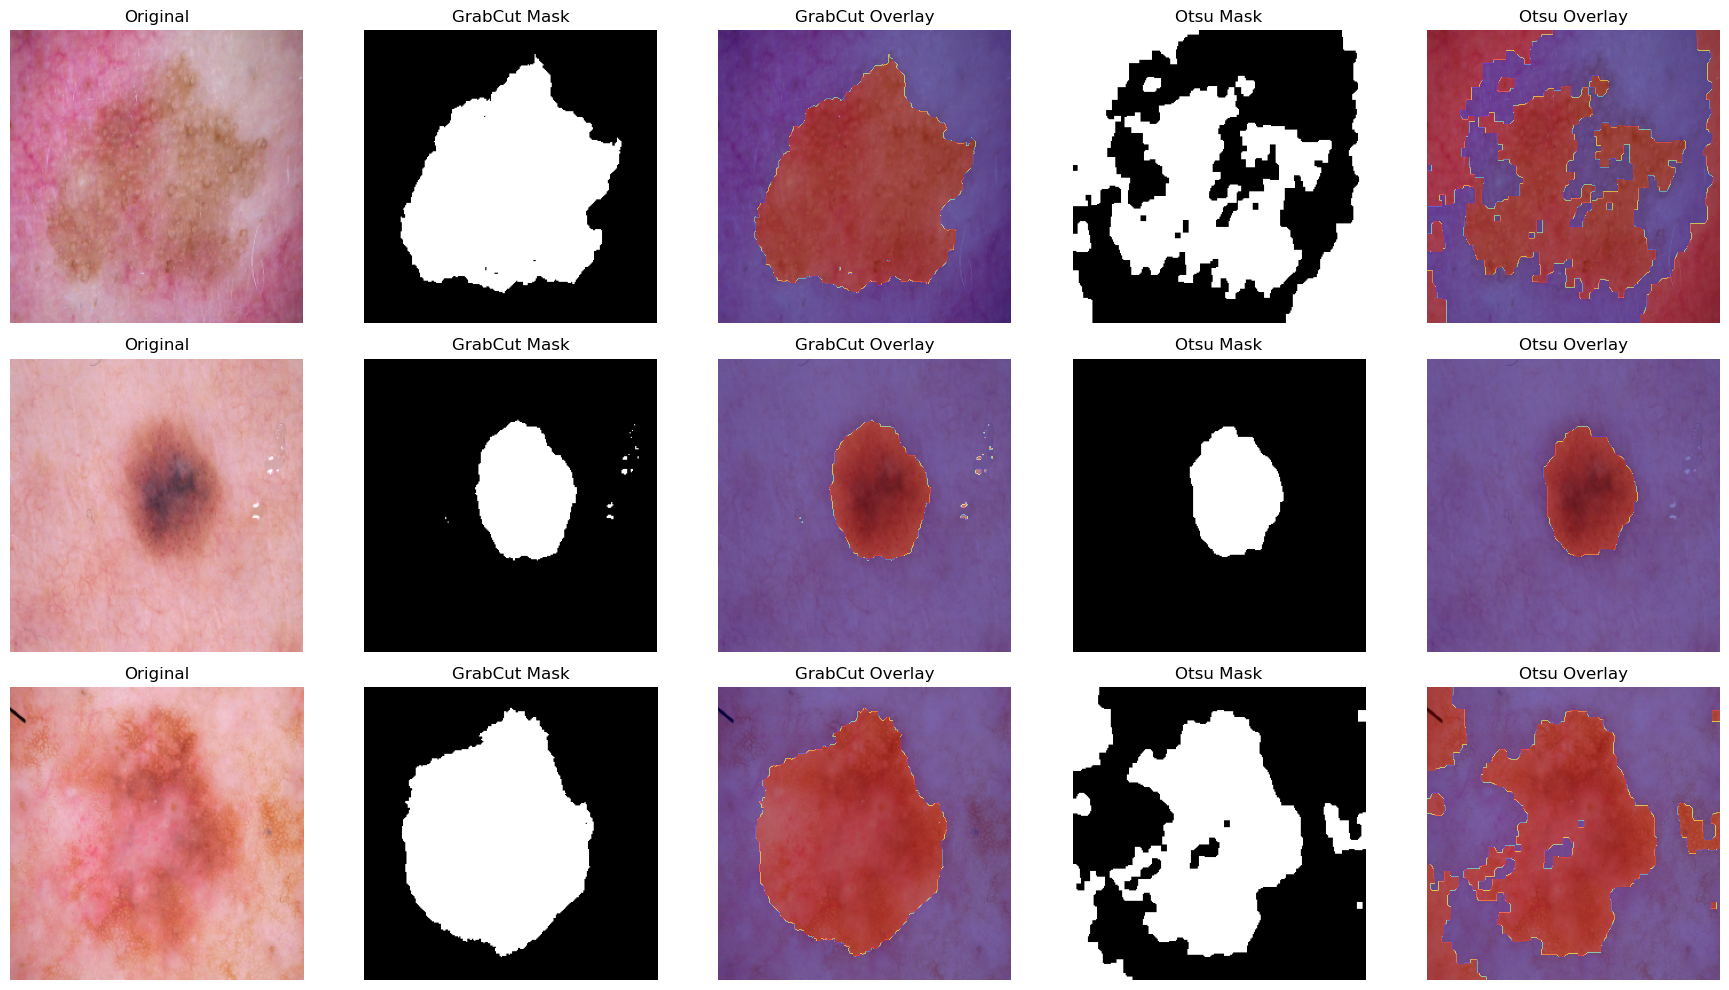

In [2]:
sample_df = df.sample(3, random_state=42).reset_index(drop=True)

sample_df[['image_id', 'dx']]

def otsu_mask(img):
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    blur = cv2.GaussianBlur(gray, (5,5), 0)

    _, mask = cv2.threshold(
        blur, 0, 255,
        cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU
    )

    kernel = np.ones((5,5), np.uint8)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)

    return mask

def grabcut_mask(img):
    mask = np.zeros(img.shape[:2], np.uint8)

    bgModel = np.zeros((1,65), np.float64)
    fgModel = np.zeros((1,65), np.float64)

    rect = (10,10,img.shape[1]-20,img.shape[0]-20)

    cv2.grabCut(img, mask, rect, bgModel, fgModel, 5, cv2.GC_INIT_WITH_RECT)

    mask2 = np.where((mask==2)|(mask==0),0,1).astype('uint8')
    return mask2*255

plt.figure(figsize=(18,10))

for i in range(3):
    
    img_path = sample_df.loc[i, 'path']
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (256,256))

    otsu = otsu_mask(img)
    grab = grabcut_mask(img)

    # Row 1
    plt.subplot(3,5,i*5+1)
    plt.title("Original")
    plt.imshow(img)
    plt.axis("off")

    plt.subplot(3,5,i*5+2)
    plt.title("GrabCut Mask")
    plt.imshow(grab, cmap='gray')
    plt.axis("off")

    plt.subplot(3,5,i*5+3)
    plt.title("GrabCut Overlay")
    plt.imshow(img)
    plt.imshow(grab, alpha=0.5, cmap='jet')
    plt.axis("off")

    plt.subplot(3,5,i*5+4)
    plt.title("Otsu Mask")
    plt.imshow(otsu, cmap='gray')
    plt.axis("off")

    plt.subplot(3,5,i*5+5)
    plt.title("Otsu Overlay")
    plt.imshow(img)
    plt.imshow(otsu, alpha=0.5, cmap='jet')
    plt.axis("off")

plt.tight_layout()
plt.show()

In [3]:
for i in range(3):
    img_path = sample_df.loc[i, 'path']
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (256,256))

    otsu = otsu_mask(img)
    grab = grabcut_mask(img)

    print(f"\nImage {i+1}")
    print("Otsu Lesion Area:", np.sum(otsu==255))
    print("GrabCut Lesion Area:", np.sum(grab==255))


Image 1
Otsu Lesion Area: 32943
GrabCut Lesion Area: 25428

Image 2
Otsu Lesion Area: 6747
GrabCut Lesion Area: 7960

Image 3
Otsu Lesion Area: 26599
GrabCut Lesion Area: 23899


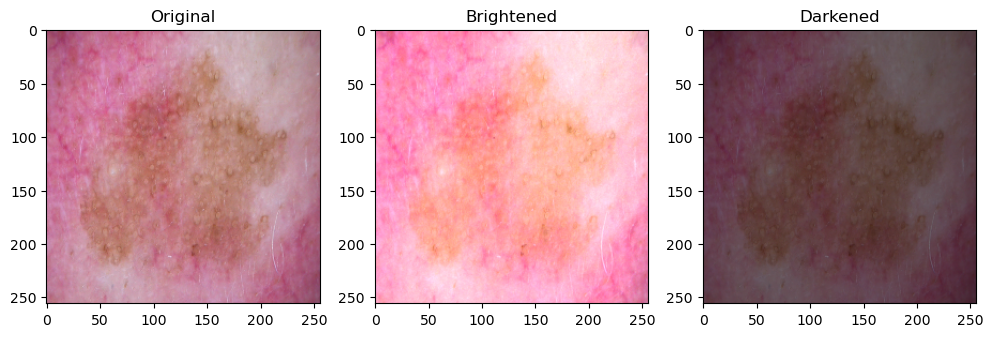

In [4]:
def change_brightness(img, factor):
    hsv = cv2.cvtColor(img, cv2.COLOR_RGB2HSV)
    hsv[:,:,2] = np.clip(hsv[:,:,2]*factor,0,255)
    return cv2.cvtColor(hsv, cv2.COLOR_HSV2RGB)

img_path = sample_df.loc[0, 'path']
img = cv2.imread(img_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img = cv2.resize(img,(256,256))

bright_img = change_brightness(img, 1.5)
dark_img = change_brightness(img, 0.5)

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.title("Original")
plt.imshow(img)

plt.subplot(1,3,2)
plt.title("Brightened")
plt.imshow(bright_img)

plt.subplot(1,3,3)
plt.title("Darkened")
plt.imshow(dark_img)

plt.show()

In [5]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

class HAMSegmentationDataset(Dataset):
    def __init__(self, dataframe):
        self.df = dataframe.reset_index(drop=True)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_path = self.df.loc[idx, 'path']
        img = cv2.imread(img_path)

        if img is None:
            img = np.zeros((256,256,3), dtype=np.uint8)

        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, (256,256))

        mask = otsu_mask(img)
        mask = cv2.resize(mask, (256,256))

        img = img / 255.0
        img = np.transpose(img, (2,0,1))
        mask = np.expand_dims(mask/255.0, axis=0)

        return torch.tensor(img, dtype=torch.float32), \
               torch.tensor(mask, dtype=torch.float32)


from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(
    df,
    test_size=0.2,
    random_state=42
)

train_loader = DataLoader(
    HAMSegmentationDataset(train_df),
    batch_size=8,
    shuffle=True
)

test_loader = DataLoader(
    HAMSegmentationDataset(test_df),
    batch_size=8,
    shuffle=False
)

print("Train:", len(train_df))
print("Test:", len(test_df))

Train: 8012
Test: 2003


In [6]:
class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.conv(x)


class UNet(nn.Module):
    def __init__(self):
        super().__init__()

        self.down1 = DoubleConv(3,64)
        self.down2 = DoubleConv(64,128)
        self.down3 = DoubleConv(128,256)

        self.pool = nn.MaxPool2d(2)

        self.up_conv1 = nn.ConvTranspose2d(256,128,2,stride=2)
        self.up1 = DoubleConv(256,128)

        self.up_conv2 = nn.ConvTranspose2d(128,64,2,stride=2)
        self.up2 = DoubleConv(128,64)

        self.final = nn.Conv2d(64,1,1)

    def forward(self,x):
        d1 = self.down1(x)
        d2 = self.down2(self.pool(d1))
        d3 = self.down3(self.pool(d2))

        u1 = self.up_conv1(d3)
        u1 = torch.cat([u1,d2], dim=1)
        u1 = self.up1(u1)

        u2 = self.up_conv2(u1)
        u2 = torch.cat([u2,d1], dim=1)
        u2 = self.up2(u2)

        return torch.sigmoid(self.final(u2))

In [7]:
def dice_loss(pred, target, smooth=1):
    pred = pred.view(-1)
    target = target.view(-1)

    intersection = (pred * target).sum()
    return 1 - ((2. * intersection + smooth) /
                (pred.sum() + target.sum() + smooth))

bce = nn.BCELoss()

def combined_loss(pred, target):
    return 0.5*bce(pred, target) + 0.5*dice_loss(pred,target)

In [8]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = UNet().to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-4)

epochs = 8

for epoch in range(epochs):
    model.train()
    total_loss = 0

    for images, masks in train_loader:
        images, masks = images.to(device), masks.to(device)

        optimizer.zero_grad()
        outputs = model(images)

        loss = combined_loss(outputs, masks)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss: {total_loss/len(train_loader):.4f}")

Epoch 1, Loss: 0.3025
Epoch 2, Loss: 0.2490
Epoch 3, Loss: 0.2377
Epoch 4, Loss: 0.2281


KeyboardInterrupt: 